In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [5]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/application_train_cleaned.csv")

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

# Same preprocessing as training
X = pd.get_dummies(X, drop_first=True)

X.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X.columns
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
rf = joblib.load("../models/random_forest_tuned.pkl")



In [7]:
def evaluate(model, name):

    pred = model.predict(X_test)

    proba = model.predict_proba(X_test)[:,1]

    result = {

        "Model": name,

        "Accuracy": accuracy_score(y_test,pred),

        "Precision": precision_score(y_test,pred),

        "Recall": recall_score(y_test,pred),

        "F1 Score": f1_score(y_test,pred),

        "ROC-AUC": roc_auc_score(y_test,proba)

    }

    return result

In [8]:
print(rf.n_features_in_)
print(X_test.shape)
print(list(X_test.columns[:10]))

181
(49202, 181)
['Unnamed__0', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION']


In [9]:
print(hasattr(rf, "feature_names_in_"))

if hasattr(rf, "feature_names_in_"):
    print(len(rf.feature_names_in_))
    print(rf.feature_names_in_[:10])

True
181
['Unnamed__0' 'CNT_CHILDREN' 'AMT_INCOME_TOTAL' 'AMT_CREDIT' 'AMT_ANNUITY'
 'AMT_GOODS_PRICE' 'REGION_POPULATION_RELATIVE' 'DAYS_BIRTH'
 'DAYS_EMPLOYED' 'DAYS_REGISTRATION']


In [10]:
print(rf.feature_names_in_[:20])

print()

print(X_test.columns[:20])

['Unnamed__0' 'CNT_CHILDREN' 'AMT_INCOME_TOTAL' 'AMT_CREDIT' 'AMT_ANNUITY'
 'AMT_GOODS_PRICE' 'REGION_POPULATION_RELATIVE' 'DAYS_BIRTH'
 'DAYS_EMPLOYED' 'DAYS_REGISTRATION' 'DAYS_ID_PUBLISH' 'FLAG_MOBIL'
 'FLAG_EMP_PHONE' 'FLAG_WORK_PHONE' 'FLAG_CONT_MOBILE' 'FLAG_PHONE'
 'FLAG_EMAIL' 'CNT_FAM_MEMBERS' 'REGION_RATING_CLIENT'
 'REGION_RATING_CLIENT_W_CITY']

Index(['Unnamed__0', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY'],
      dtype='str')


In [11]:
set(rf.feature_names_in_) - set(X_test.columns)

set()

In [12]:
set(X_test.columns) - set(rf.feature_names_in_)

set()

In [13]:
results = []

results.append(evaluate(rf,"Random Forest"))

results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.909069,0.216155,0.047799,0.078286,0.692083


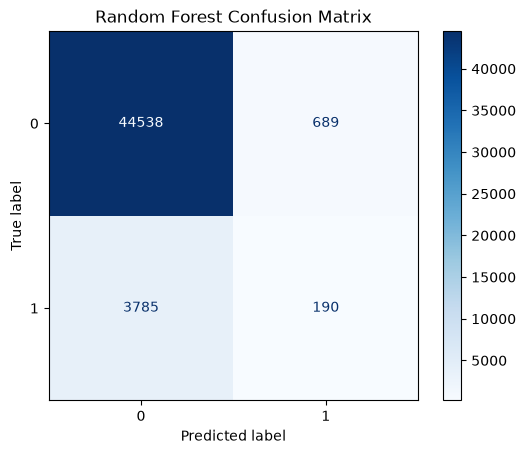

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

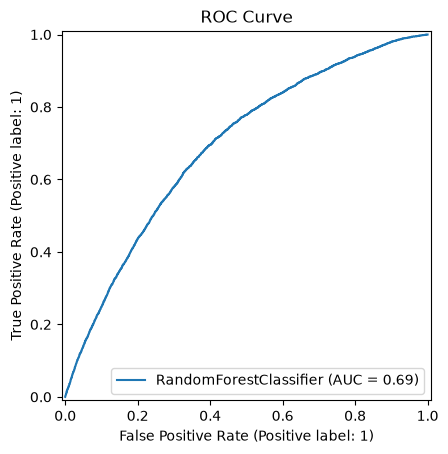

In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

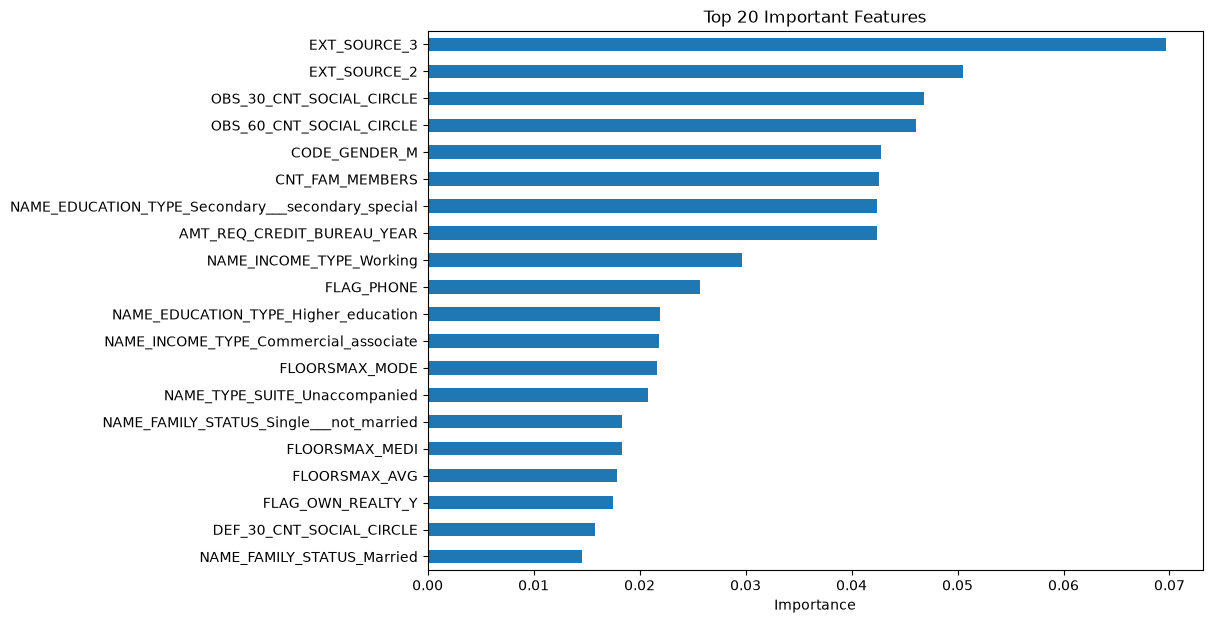

In [16]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)
importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

In [17]:
import shap

In [18]:
explainer = shap.TreeExplainer(rf)

In [22]:
X_values = X_test.sample(500, random_state=42)

InvalidIndexError: (slice(None, None, None), 14)

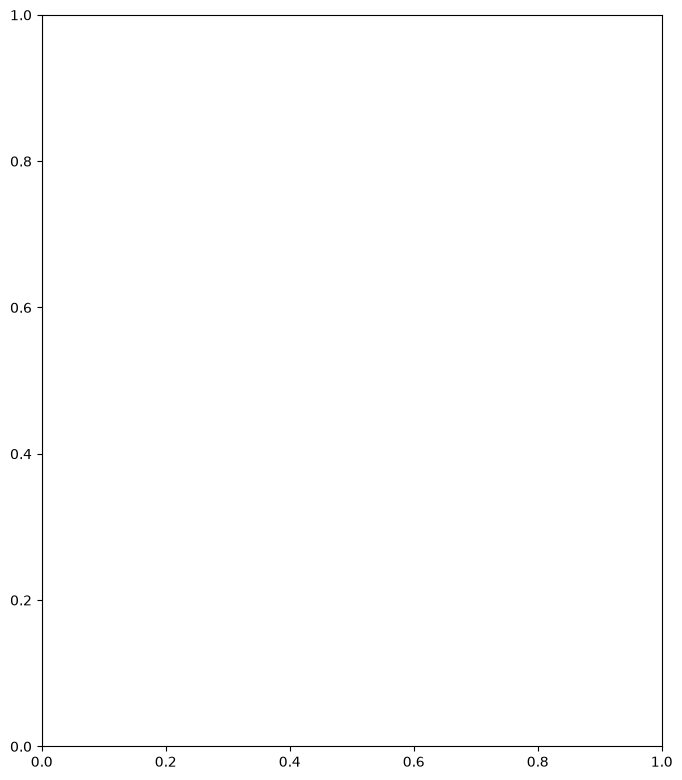

In [ ]:
# X_values already contains the 500-row sample from the previous cell
shap_values = explainer.shap_values(X_values)

shap.summary_plot(
    shap_values,
    X_values
)